In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme()

In [42]:
data = pd.read_csv("analysis/position-control-open-loop/data.csv")
data.loc[data.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis

/tmp/ipykernel_53077/3281521984.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.311' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[data.delay_k==0, "delay_k"] = 0.311 #Cosmetic, for log x-axis


In [43]:
regular_pos = data[data.condition == "pos_efference"].sort_values("delay_k").groupby("delay_k").first()
regular_torque = data[data.condition == "torque_efference_aug11"].sort_values("delay_k").groupby("delay_k").first()

/tmp/ipykernel_53077/4204792567.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


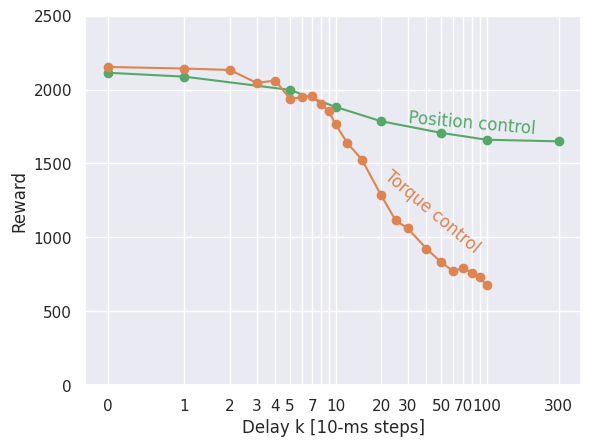

In [47]:
plt.semilogx(regular_pos.index, regular_pos.old_eval_reward, 'o-', color="C2")
plt.semilogx(regular_torque.index, regular_torque.old_eval_reward, 'o-', color="C1")
plt.ylim(0, 2500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,300]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100,300]
plt.xticks(xticks,xticklabels)
plt.legend(frameon=False)
plt.text(30, 1700, "Position control", rotation=-5, color="C2")
plt.text(20, 900, "Torque control", rotation=-40, color="C1")
#plt.text(12, 1400, "LSTM decoder", color="C4", rotation=-45)
plt.show()

/tmp/ipykernel_53077/777389066.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


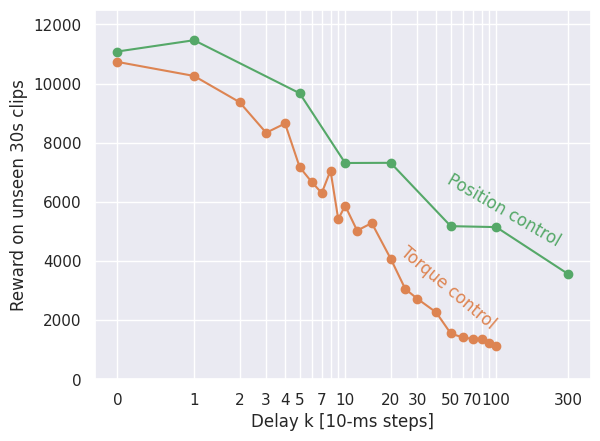

In [63]:
plt.semilogx(regular_pos.index, regular_pos.new_eval_reward, 'o-', color="C2")
plt.semilogx(regular_torque.index, regular_torque.new_eval_reward, 'o-', color="C1")
plt.ylim(0, 12500)
plt.xlabel("Delay k [10-ms steps]")
plt.ylabel("Reward on unseen 30s clips")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,300]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100,300]
plt.xticks(xticks,xticklabels)
plt.legend(frameon=False)
plt.text(45, 4500, "Position control", rotation=-30, color="C2")
plt.text(22, 1700, "Torque control", rotation=-40, color="C1")
#plt.text(12, 1400, "LSTM decoder", color="C4", rotation=-45)
plt.show()

In [75]:
open_loop_data = pd.read_csv("analysis/efference-copy-vs-proprioception/data.csv")
open_loop_data.loc[open_loop_data.efference_length==0, "efference_length"] = 0.311 #Cosmetic, for log x-axis
open_loop_data = open_loop_data[open_loop_data.state == "finished"]

In [76]:
pos_noproprio = open_loop_data[open_loop_data.condition=="pos_noproprio"]
torque_noproprio = open_loop_data[open_loop_data.condition=="torque_noproprio"]

/tmp/ipykernel_53077/3064381304.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


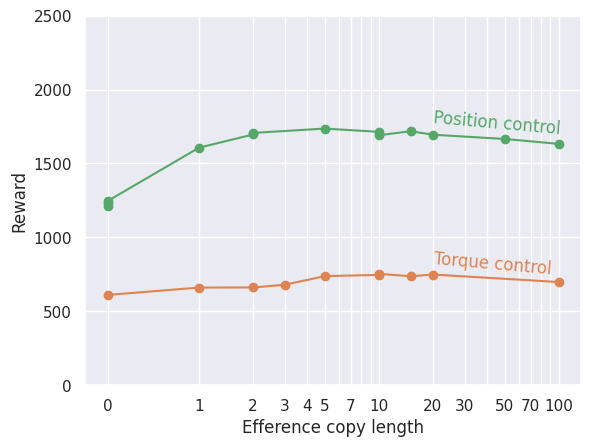

In [87]:
plt.semilogx(torque_noproprio.efference_length, torque_noproprio.reward_600M, '-o', color="C1")
plt.semilogx(pos_noproprio.efference_length, pos_noproprio.reward_600M, '-o', color="C2")
plt.ylim(0, 2500)
plt.xlabel("Efference copy length")
plt.ylabel("Reward")
xticks = [0.311, 1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]
xticklabels = [0, 1,2,3,4,5,"",7,"","",10,20,30,"",50,"",70,"","",100]
plt.xticks(xticks,xticklabels)
plt.legend(frameon=False)
plt.text(20, 1700, "Position control", rotation=-5, color="C2")
plt.text(20, 750, "Torque control", rotation=-5, color="C1")
#plt.text(12, 1400, "LSTM decoder", color="C4", rotation=-45)
plt.show()

In [80]:
torque_noproprio.columns

Index(['condition', 'wandb_id', 'wandb_name', 'state', 'created_at',
       'git_commit', 'gpu', 'mode', 'efference_length', 'delay_k',
       'use_intention', 'use_proprioception', 'decoder_in_width',
       'actual_step', 'hist_max_step', 'eval_points', 'eval_split',
       'repos_dirty', 'reward_600M', 'lifespan_600M', 'reward_per_step_600M',
       'window_points_600M', 'window_last_step_600M', 'window_complete_600M',
       'reward_400M', 'lifespan_400M', 'reward_per_step_400M',
       'window_points_400M', 'window_last_step_400M', 'window_complete_400M',
       'usable_600M', 'usable_400M'],
      dtype='object')